<a href="https://colab.research.google.com/github/nganvuda/ML-model-Multiple-Linear-Regression-Random-Forest/blob/main/AI_ML_Linear_reg_RanForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Load all needed libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import warnings

warnings.filterwarnings('ignore')


In [ ]:
# Open path to Google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Assign file paths and rename the dataset file to cleaned_dataset
input_path = r"/content/drive/MyDrive/Colab Notebooks/Dataset-Assessment 2.csv"
output_path = r"/content/drive/MyDrive/Colab Notebooks/cleaned_dataset.csv"

# Load the raw dataset
df = pd.read_csv(input_path)


In [ ]:
import pandas as pd

# # 1. create input output paths in drive C
# input_path = r"C:\assessment2\Dataset-Assessment.csv"
# output_path = r"C:\assessment2\cleaned_dataset.csv"

# # 2. Loading our the dataset
# df = pd.read_csv(input_path)

# 3. Showing data and check column types
print(df.head())
print(df.info())

# 4. Removing the rows in dataset with none or missing values
df = df.dropna()

# 5. we also remove duplicates
df = df.drop_duplicates()

# 6. Extract numbers and convert to numeric type
df['FuelConsumption'] = pd.to_numeric(df['FuelConsumption'].astype(str).str.extract(r'(\d+\.?\d*)')[0], errors='coerce')
df['CylindersinEngine'] = pd.to_numeric(df['CylindersinEngine'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df['Doors'] = pd.to_numeric(df['Doors'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df['Seats'] = pd.to_numeric(df['Seats'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df['Engine'] = pd.to_numeric(df['Engine'].astype(str).str.extract(r'(\d+\.?\d*)')[0], errors='coerce')

#  Clean the data, convert to numeric by removing commas etc
df['Kilometres'] = pd.to_numeric(df['Kilometres'].astype(str).str.replace(",", ""), errors='coerce')
df['Price'] = pd.to_numeric(df['Price'].astype(str).str.replace(",", ""), errors='coerce')

# 7. Deletes any row where one of these important columns is still empty
df = df.dropna(subset=['FuelConsumption', 'CylindersinEngine', 'Doors', 'Seats', 'Kilometres', 'Price'])

# 8. Reset index for Do not keep the old row numbers as a new column.
df = df.reset_index(drop=True)

# 9. Save cleaned dataset
df.to_csv(output_path, index=False)

print("✅ Cleaned dataset saved at:", output_path)

           Brand    Year   Model               Car/Suv  \
0      Ssangyong  2022.0  Rexton  Sutherland Isuzu Ute   
1             MG  2022.0     MG3             Hatchback   
2            BMW  2022.0    430I                 Coupe   
3  Mercedes-Benz  2011.0    E500                 Coupe   
4        Renault  2022.0  Arkana                   SUV   

                                       Title UsedOrNew Transmission  \
0       2022 Ssangyong Rexton Ultimate (awd)      DEMO    Automatic   
1  2022 MG MG3 Auto Excite (with Navigation)      USED    Automatic   
2                      2022 BMW 430I M Sport      USED    Automatic   
3           2011 Mercedes-Benz E500 Elegance      USED    Automatic   
4                 2022 Renault Arkana Intens      USED    Automatic   

         Engine DriveType  FuelType FuelConsumption Kilometres   ColourExtInt  \
0  4 cyl, 2.2 L       AWD    Diesel  8.7 L / 100 km       5595  White / Black   
1  4 cyl, 1.5 L     Front   Premium  6.7 L / 100 km         16

In [ ]:

# Linear Regression
# Reload the cleaned dataset
df_cleaned = pd.read_csv(output_path)

# Select relevant features (independent variables)
features = ['Year', 'Kilometres', 'Engine', 'CylindersinEngine', 'FuelConsumption', 'Doors', 'Seats']
X = df_cleaned[features].fillna(0)  # Ensure no missing values remain

# Select target variable (dependent variable)
y = df_cleaned['Price']

# Check the first few rows to confirm all are numeric
print(X.head())
print(X.dtypes)




     Year  Kilometres  Engine  CylindersinEngine  FuelConsumption  Doors  \
0  2022.0      5595.0       4                  4              8.7      4   
1  2022.0        16.0       4                  4              6.7      5   
2  2022.0      8472.0       4                  4              6.6      2   
3  2011.0    136517.0       8                  8             11.0      2   
4  2022.0      1035.0       4                  4              6.0      4   

   Seats  
0      7  
1      5  
2      4  
3      4  
4      5  
Year                 float64
Kilometres           float64
Engine                 int64
CylindersinEngine      int64
FuelConsumption      float64
Doors                  int64
Seats                  int64
dtype: object


In [ ]:

# Training the Linear Regression Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
# ----------------- Added: Split data into train and test sets -----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
# ------------------------------------------------------------------------------

# Create the linear regression model
model = LinearRegression()

# Train the model using the features and target
model.fit(X_train, y_train)
# model.fit(X, y)

# ----------------- Added: Predict on test data -----------------
y_pred = model.predict(X_test)
# ---------------------------------------------------------------

# Result
# Display the learned coefficients and intercept
print("\nModel: Multiple Linear Regression")
print(f"Intercept (Base Price): {model.intercept_:.2f}")
print("Coefficients per feature:")
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef:.2f}")

    # ----------------- Added: Evaluate the model -----------------
print("\nEvaluation on Test Set:")
lr_r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {lr_r2:.3f}")
lr_mse = mean_squared_error(y_test, y_pred)
lr_rsme = np.sqrt(lr_mse)
# print("Mean Squared Error:", lr_mse)
print(f"rsme: {lr_rsme:.2f}")
# --------------------------------------------------------------


Model: Multiple Linear Regression
Intercept (Base Price): -4182748.17
Coefficients per feature:
Year: 2082.20
Kilometres: -0.09
Engine: 5605.73
CylindersinEngine: 5605.73
FuelConsumption: -619.45
Doors: -5453.81
Seats: 1075.98

Evaluation on Test Set:
R^2 Score: 0.363
rsme: 24196.64


In [ ]:
# Megan- Random Forest Regressor Task
# Load the cleaned dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cleaned_dataset.csv")
features = ['Year', 'Kilometres', 'Engine', 'CylindersinEngine', 'FuelConsumption', 'Doors', 'Seats']
X = df[features]
y = df['Price']

In [ ]:
# Split the data
# Import train_test_split from sklearn
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (11563, 7)
Test size: (2891, 7)


In [ ]:
# Train the model Random Forest
from sklearn.ensemble import RandomForestRegressor
# Instantiate the Random Forest Regressor, train model on training data
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [ ]:
# Evaluate model performance (R² and RMSE)
# --------------
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Predict on test set
y_pred = rf_model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.3f}")
print(f"RMSE: ${rmse:,.0f}")



R² Score: 0.660
RMSE: $17,675



R² (coefficient of determination) measures the proportion of variance in the target (car price) that is explained by the model. An R² of 1.0 means the model perfectly explains the data, while 0.0 means it does no better than predicting the mean.

RMSE (Root Mean Squared Error) is the square root of the average squared difference between predicted and actual values. It is in the same units as the target (dollars, in this case) and lower values indicate better predictions (with 0 being a perfect score).

The R² score is a unitless measure between 0 and 1, where higher is better. The RMSE is in the same unit as the prices; here we formatted it with two decimal places.

Kilometres           0.308310
Year                 0.191963
Engine               0.156261
CylindersinEngine    0.148527
FuelConsumption      0.139546
Seats                0.033624
Doors                0.021770
dtype: float64


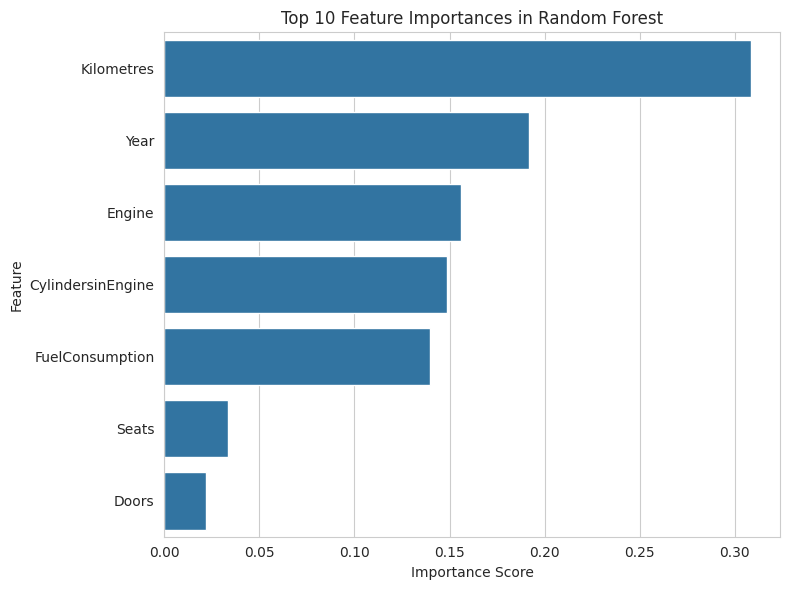

In [ ]:
# Identify which features were most important in the Random Forest model for predicting car prices

# Import potting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for feature importance plot
# Get feature names from X (if X is a DataFrame) or use generic names if not
import pandas as pd
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f"Feature {i}" for i in range(X_train.shape[1])]

# Create a pandas Series of feature importances for easy handling
importances = pd.Series(rf_model.feature_importances_, index=feature_names)

# Select the top 10 features by importance
top_10_importances = importances.nlargest(10)
print(top_10_importances)
# Set up the matplotlib figure
plt.figure(figsize=(8, 6))
# optional: set a style for the plot
sns.set_style("whitegrid")

# Create a horizontal bar plot of the top 10 feature importances
sns.barplot(x=top_10_importances.values, y=top_10_importances.index, orient='h')

# Add chart labels and title
plt.title("Top 10 Feature Importances in Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

# Adjust layout for readability
plt.tight_layout()
plt.show()

In the plot, features are listed on the y-axis and their importance scores on the x-axis. The top feature (at the top of the chart) is the most influential in predicting car price according to the Random Forest model.

This visualization helps us understand which factors (e.g., brand, year, mileage, etc.) have the biggest impact on the predicted price.

lr_r2 = 0.363
rf_r2 = 0.660


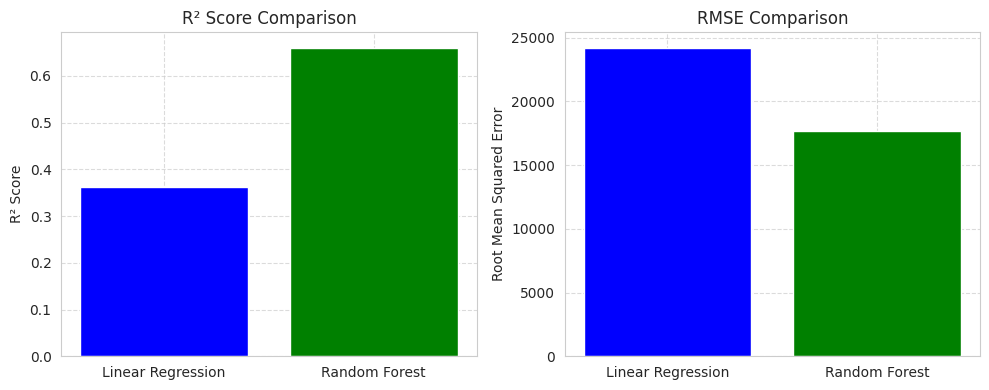

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
print(f"lr_r2 = {lr_r2:.3f}")
print(f"rf_r2 = {rf_r2:.3f}")

r2_values = [lr_r2, rf_r2]
rmse_values = [lr_rsme, rf_rmse]
models = ['Linear Regression', 'Random Forest']

# Plotting
plt.figure(figsize=(10, 4))

# R² Score Bar Plot
plt.subplot(1, 2, 1)
plt.bar(models, r2_values, color=['blue', 'green'])
plt.title('R² Score Comparison')
plt.ylabel('R² Score')
plt.grid(True, linestyle='--', alpha=0.7)

# RMSE Bar Plot
plt.subplot(1, 2, 2)
plt.bar(models, rmse_values, color=['blue', 'green'])
plt.title('RMSE Comparison')
plt.ylabel('Root Mean Squared Error')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()